In [28]:
import numpy as np
import matplotlib.pyplot as plt

n=100
C_0=90
L=10
delta=n/L
lamda=0.000
a=1/(3-(delta/lamda))
def bijection(i,j):
    return i+n*(j-1)
def reciproque(k):
    j=(k//n)+1
    i=k-(n*(j-1))
    if (i==0):
        return[i+10,j-1]
    else:
        return[i,j]
c=np.zeros((n*n,n*n))
h=np.zeros(n*n)
d=np.zeros(n*n)
for i in range(2,n-1):
    h[i+(n*n)-n]=C_0
    c[i+(n*n)-n][i+(n*n)-n]=1
    d=np.append(d,i+(n*n)-n)
for j in range(2,n-1):
    c[(n*(j-1))][(n*(j-1))+1]=-1/3
    c[(n*(j-1))][(n*(j-1))+n]=-1/3
    c[(n*(j-1))][(n*(j-1))-n]=-1/3
    c[(n*(j-1))][(n*(j-1))]=1
    d=np.append(d,n*(j-1))
for j in range(2,n-1):
    c[n+(n*(j-1))-1][n+(n*(j-1))]=-1/3
    c[n+(n*(j-1))-1][n+(n*(j-1))+n-1]=-1/3
    c[n+(n*(j-1))-1][(n*(j-1))-1]=-1/3
    c[n+(n*(j-1))-1][n+(n*(j-1))-1]=1
    d=np.append(d,n+(n*(j-1))-1)
for i in range(0,n):
    c[i][i+1]=-a
    c[i][i-1]=-a
    c[i][i+n]=-a
    c[i][i]=1
    d=np.append(d,i)
for k in range(0,n*n):
    if k not in d:
        c[k][k+n]=-1/4
        c[k][k-n]=-1/4
        c[k][k+1]=-1/4
        c[k][k-1]=-1/4
        c[k][k]=1
X=np.dot(np.linalg.inv(c),h)
b=np.zeros((n,n))
for k in range(0,n*n):
    l=reciproque(k+1)
    i=l[0]-1
    j=l[1]-1
    b[j,i]=X[k]

IndexError: index 10000 is out of bounds for axis 0 with size 10000

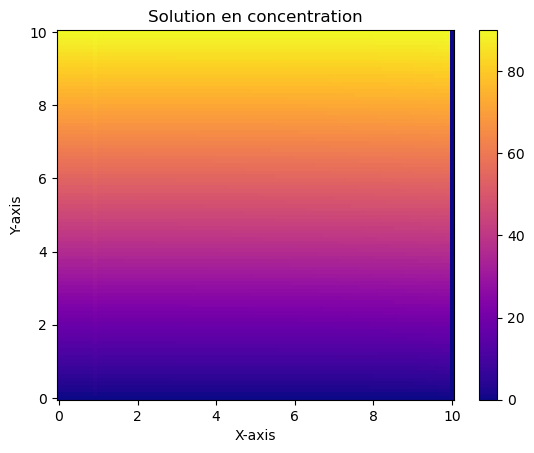

In [8]:
z = np.linspace(0, L, n)
y = np.linspace(0, L, n)
Z, Y = np.meshgrid(z, y)
# Plotting the results
plt.pcolormesh(Z, Y, b, cmap='plasma')  # You can also use plt.pcolormesh for a different style
#plt.contourf(Z, Y, b, cmap='plasma')  # You can also use plt.pcolormesh for a different style
plt.colorbar()  # Add a colorbar for reference
plt.title('Solution en concentration')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()